# Captioning : CNN vers GRU

Images synthétiques de formes colorées, légendes à deux attributs. Objectif : suivre image→état→tokens et comparer teacher forcing à génération autonome. CPU, aucune donnée externe.

## 1. Images, tokens et cibles décalées

Les formes bougent et les pixels sont bruités. Le test utilise une autre graine. Toutes les combinaisons de concepts restent possibles dans les deux ensembles.

In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.set_num_threads(1); torch.manual_seed(42)
vocab = ['PAD','BOS','EOS','carre','barre','rouge','vert']
def dataset(n,seed):
    rng = np.random.default_rng(seed)
    images = np.zeros((n,3,12,12),dtype=np.float32)
    captions = []
    for i in range(n):
        shape,color = rng.integers(0,2,size=2)
        row,col = rng.integers(1,5,size=2)
        height,width = (4,4) if shape==0 else (6,2)
        images[i,color,row:row+height,col:col+width] = 1
        images[i] += rng.normal(0,.025,images[i].shape)
        captions.append([3+shape,5+color,2])
    return torch.tensor(images),torch.tensor(captions)
x,y = dataset(400,42); xt,yt = dataset(100,43)
inputs = torch.cat([torch.ones(len(y),1,dtype=torch.long),y[:,:-1]],dim=1)
assert inputs.shape == y.shape == (400,3)

## 2. Encodeur et décodeur

La représentation visuelle initialise la GRU. Les cibles sont forme, couleur, EOS. PAD est ignoré par la loss pour permettre une extension à longueurs variables.

In [2]:
class Captioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(3,8,3,padding=1),nn.ReLU(),nn.Flatten(),nn.Linear(8*12*12,32),nn.Tanh())
        self.embedding = nn.Embedding(len(vocab),16,padding_idx=0)
        self.gru = nn.GRU(16,32,batch_first=True)
        self.head = nn.Linear(32,len(vocab))
    def forward(self,image,tokens):
        hidden = self.encoder(image).unsqueeze(0)
        output,_ = self.gru(self.embedding(tokens),hidden)
        return self.head(output)
    def generate(self,image):
        hidden = self.encoder(image).unsqueeze(0)
        token = torch.ones(len(image),1,dtype=torch.long)
        predictions = []
        for _ in range(3):
            output,hidden = self.gru(self.embedding(token),hidden)
            token = self.head(output).argmax(-1)
            predictions.append(token)
        return torch.cat(predictions,dim=1)
model = Captioner()
opt = torch.optim.Adam(model.parameters(),lr=.008)
for step in range(240):
    ids = torch.randint(len(x),(64,))
    logits = model(x[ids],inputs[ids])
    loss = nn.functional.cross_entropy(logits.reshape(-1,len(vocab)),y[ids].reshape(-1),ignore_index=0)
    opt.zero_grad(); loss.backward(); opt.step()
assert logits.shape == (64,3,len(vocab))

## 3. Générer sans vrais préfixes

Exact match exige les deux attributs et EOS. L’ablation sans image mesure l’apport du signal visuel. La génération a une borne de trois pas adaptée au vocabulaire du jouet.

{'légendes exactes test': 1.0, 'images supprimées': 0.23000000417232513}


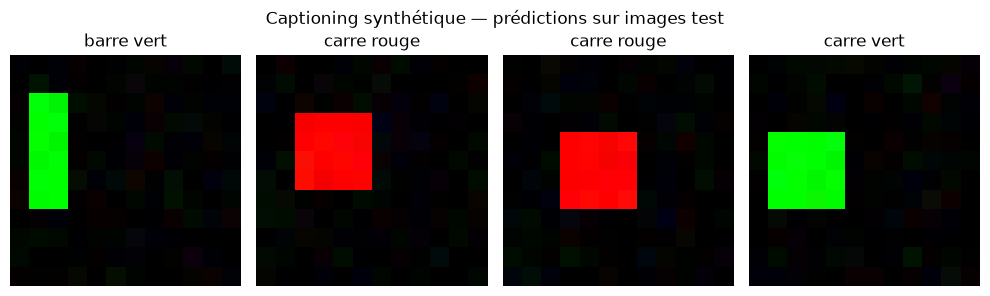

In [3]:
model.eval()
with torch.no_grad():
    predicted = model.generate(xt)
    blank = model.generate(torch.zeros_like(xt))
    exact = (predicted==yt).all(1).float().mean().item()
    blank_exact = (blank==yt).all(1).float().mean().item()
assert exact > .65, 'Le jouet doit apprendre les deux attributs ; examiner loss et images.'
print({'légendes exactes test':exact,'images supprimées':blank_exact})
fig,axes = plt.subplots(1,4,figsize=(10,3))
for i,ax in enumerate(axes):
    ax.imshow(xt[i].permute(1,2,0).clamp(0,1))
    ax.set_title(' '.join(vocab[j] for j in predicted[i].tolist() if j not in [0,1,2]))
    ax.axis('off')
fig.suptitle('Captioning synthétique — prédictions sur images test'); plt.tight_layout(); plt.show()

## Exercice

Retenez une combinaison uniquement pour le test. Pourquoi un exact match élevé ici ne suffit-il pas pour des légendes de photographies ?

In [4]:
# Écrivez votre expérience ici avant de lire la correction.

## Correction et limites

Le vocabulaire, les objets et la syntaxe sont minuscules ; le test est issu du même générateur. Un test de combinaison inédite examine une autre généralisation. Sur des photos, ajouter fidélité, paraphrases, comptage, relations spatiales et évaluations humaines.